In [4]:
import os
import datetime
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch_directml

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


device = torch_directml.device(0)  
print(f'Device: {torch_directml.device_name(0)}')

Device: AMD Radeon RX 7600S 


In [5]:
DATA_MODES = ['train', 'val', 'test']

TRAIN_DIR = Path('journey-springfield/train/simpsons_dataset')
TEST_DIR  = Path('journey-springfield/test/testset')

NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD  = [0.229, 0.224, 0.225]

RESCALE_SIZE = [224, 224]   
BATCH_SIZE   = 32
EPOCHS       = 10
LR           = 1e-4        

In [6]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files      = sorted(list(TEST_DIR.rglob('*.jpg')))

print(f'Train+Val rasmlari: {len(train_val_files)}')
print(f'Test rasmlari:      {len(test_files)}')

label_encoder = LabelEncoder()
train_val_labels = [path.parent.name for path in train_val_files]
label_encoder.fit(train_val_labels)

n_classes = len(label_encoder.classes_)
print(f'Sinflar soni: {n_classes}')
print(f'Sinflar: {list(label_encoder.classes_)}')

Train+Val rasmlari: 20933
Test rasmlari:      992
Sinflar soni: 42
Sinflar: [np.str_('abraham_grampa_simpson'), np.str_('agnes_skinner'), np.str_('apu_nahasapeemapetilon'), np.str_('barney_gumble'), np.str_('bart_simpson'), np.str_('carl_carlson'), np.str_('charles_montgomery_burns'), np.str_('chief_wiggum'), np.str_('cletus_spuckler'), np.str_('comic_book_guy'), np.str_('disco_stu'), np.str_('edna_krabappel'), np.str_('fat_tony'), np.str_('gil'), np.str_('groundskeeper_willie'), np.str_('homer_simpson'), np.str_('kent_brockman'), np.str_('krusty_the_clown'), np.str_('lenny_leonard'), np.str_('lionel_hutz'), np.str_('lisa_simpson'), np.str_('maggie_simpson'), np.str_('marge_simpson'), np.str_('martin_prince'), np.str_('mayor_quimby'), np.str_('milhouse_van_houten'), np.str_('miss_hoover'), np.str_('moe_szyslak'), np.str_('ned_flanders'), np.str_('nelson_muntz'), np.str_('otto_mann'), np.str_('patty_bouvier'), np.str_('principal_skinner'), np.str_('professor_john_frink'), np.str_('raini

In [7]:
train_files, val_files = train_test_split(
    train_val_files,
    test_size=0.25,
    stratify=train_val_labels,
    random_state=42
)
print(f'Train: {len(train_files)} | Val: {len(val_files)}')

Train: 15699 | Val: 5234


In [8]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        assert mode in DATA_MODES, f"{mode} noto'g'ri. To'g'ri modlar: {DATA_MODES}"
        self.files         = sorted(files)
        self.mode          = mode
        self.label_encoder = label_encoder
        self.len_          = len(self.files)

    def __len__(self):
        return self.len_

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.apply_transforms(x)
        if self.mode == 'test':
            return x
        y = self.label_encoder.transform([self.files[index].parent.name]).item()
        return x, y

    def load_image(self, file):
        image = Image.open(file).convert('RGB')  
        return image

    def apply_transforms(self, image):
        if self.mode == 'train':
            transform = v2.Compose([
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),

                # 1
                v2.RandomHorizontalFlip(p=0.5),

                # 2
                v2.RandomRotation(degrees=35),

                # 3
                v2.ColorJitter(
                    brightness=0.3,
                    contrast=0.3,
                    saturation=0.2,
                    hue=0.05
                ),

                # 4
                v2.RandomGrayscale(p=0.1),

                v2.Resize(RESCALE_SIZE),
                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            ])
        else:
            transform = v2.Compose([
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Resize(RESCALE_SIZE),
                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            ])
        return transform(image)

In [9]:
train_dataset = SimpsonsDataset(train_files, label_encoder, mode='train')
val_dataset   = SimpsonsDataset(val_files,   label_encoder, mode='val')
test_dataset  = SimpsonsDataset(test_files,  label_encoder, mode='test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 491 | Val batches: 164


In [10]:
def build_model(n_classes, freeze_backbone=False):

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),               
        nn.Linear(in_features, n_classes)
    )

    return model


model = build_model(n_classes=n_classes, freeze_backbone=False)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Jami parametrlar:    {total_params:,}')
print(f"O'rganuvchi params:  {trainable_params:,}")

Jami parametrlar:    11,198,058
O'rganuvchi params:  11,198,058


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

In [12]:
def train_one_epoch(model, optimizer, criterion, dataloader, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for data, label in tqdm(dataloader, desc='Train', leave=False):
        data, label = data.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss   = criterion(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(output.argmax(dim=1).cpu().numpy())
        all_labels.extend(label.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='micro')
    return total_loss / len(dataloader), f1


@torch.no_grad()
def eval_one_epoch(model, criterion, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for data, label in tqdm(dataloader, desc='Val  ', leave=False):
        data, label = data.to(device), label.to(device)

        output = model(data)
        loss   = criterion(output, label)

        total_loss += loss.item()
        all_preds.extend(output.argmax(dim=1).cpu().numpy())
        all_labels.extend(label.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='micro')
    return total_loss / len(dataloader), f1

In [13]:
train_losses, val_losses = [], []
train_f1s,    val_f1s    = [], []
best_f1     = 0.0

os.makedirs('checkpoint', exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1 = train_one_epoch(model, optimizer, criterion, train_loader, device)
    vl_loss, vl_f1 = eval_one_epoch(model, criterion, val_loader, device)

    scheduler.step(vl_loss)

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_f1s.append(tr_f1)
    val_f1s.append(vl_f1)

    if vl_f1 > best_f1:
        best_f1 = vl_f1
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optimizer':   optimizer.state_dict(),
            'f1':          best_f1,
        }, './checkpoint/best_resnet18.pth')

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f}, F1: {tr_f1:.4f} | '
          f'Val Loss: {vl_loss:.4f}, F1: {vl_f1:.4f}'
          + (' ✅ SAVED' if vl_f1 == best_f1 else ''))

print(f'\nEng yaxshi Val F1: {best_f1:.4f}')

Epoch 01/10 | Train Loss: 1.0631, F1: 0.7513 | Val Loss: 0.3295, F1: 0.9240 ✅ SAVED


Epoch 02/10 | Train Loss: 0.3693, F1: 0.9107 | Val Loss: 0.2145, F1: 0.9484 ✅ SAVED


Epoch 03/10 | Train Loss: 0.2496, F1: 0.9394 | Val Loss: 0.1689, F1: 0.9603 ✅ SAVED


Epoch 04/10 | Train Loss: 0.1862, F1: 0.9558 | Val Loss: 0.1432, F1: 0.9664 ✅ SAVED


Epoch 05/10 | Train Loss: 0.1496, F1: 0.9627 | Val Loss: 0.1451, F1: 0.9643


Epoch 06/10 | Train Loss: 0.1263, F1: 0.9690 | Val Loss: 0.1303, F1: 0.9683 ✅ SAVED


Epoch 07/10 | Train Loss: 0.1014, F1: 0.9745 | Val Loss: 0.1186, F1: 0.9734 ✅ SAVED


Epoch 08/10 | Train Loss: 0.0991, F1: 0.9745 | Val Loss: 0.1220, F1: 0.9694


Epoch 09/10 | Train Loss: 0.0816, F1: 0.9785 | Val Loss: 0.1220, F1: 0.9719


Epoch 10/10 | Train Loss: 0.0785, F1: 0.9790 | Val Loss: 0.1443, F1: 0.9666

Eng yaxshi Val F1: 0.9734


In [12]:
for i in range(torch_directml.device_count()):
    print(f"Index {i}: {torch_directml.device_name(i)}")

Index 0: AMD Radeon RX 7600S 
Index 1: AMD Radeon(TM) Graphics 


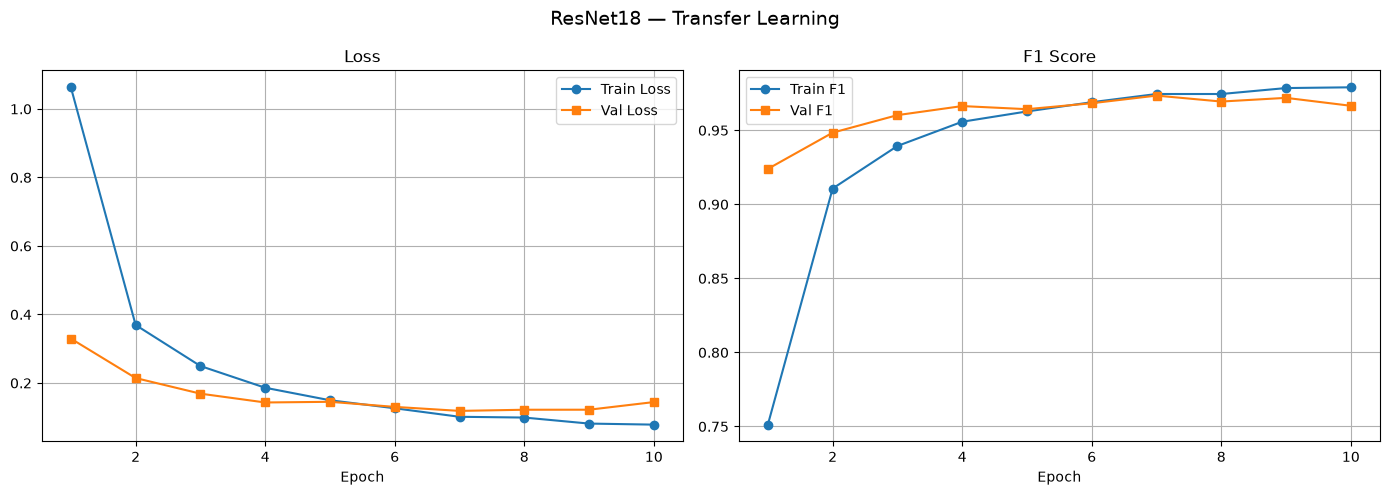

In [14]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_losses, label='Train Loss', marker='o')
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   marker='s')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_f1s, label='Train F1', marker='o')
axes[1].plot(epochs_range, val_f1s,   label='Val F1',   marker='s')
axes[1].set_title('F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('ResNet18 — Transfer Learning', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
checkpoint = torch.load('./checkpoint/best_resnet18.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state'])

model = model.to(device)

print(f"Epoch {checkpoint['epoch']} dagi model yuklandi. Val F1: {checkpoint['f1']:.4f}")

Epoch 7 dagi model yuklandi. Val F1: 0.9734


In [19]:
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    all_preds = []
    for inputs in tqdm(loader, desc='Inference'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
    return np.array(all_preds)


predicted_numeric = predict(model, test_loader, device)
predicted_labels  = label_encoder.inverse_transform(predicted_numeric)

preds_df = pd.DataFrame({
    'Id':       [path.name for path in test_files],   
    'Expected': predicted_labels                     
})

print(f'Jami bashoratlar: {len(preds_df)}')
preds_df.head(10)

Inference: 100%|██████████| 31/31 [00:15<00:00,  1.97it/s]

Jami bashoratlar: 992


,Id,Expected
0,img0-checkpoint.jpg,nelson_muntz
1,img0.jpg,nelson_muntz
2,img1.jpg,bart_simpson
3,img10.jpg,ned_flanders
4,img100.jpg,chief_wiggum
5,img101.jpg,apu_nahasapeemapetilon
6,img102.jpg,kent_brockman
7,img103.jpg,edna_krabappel
8,img104.jpg,chief_wiggum
9,img105.jpg,lisa_simpson


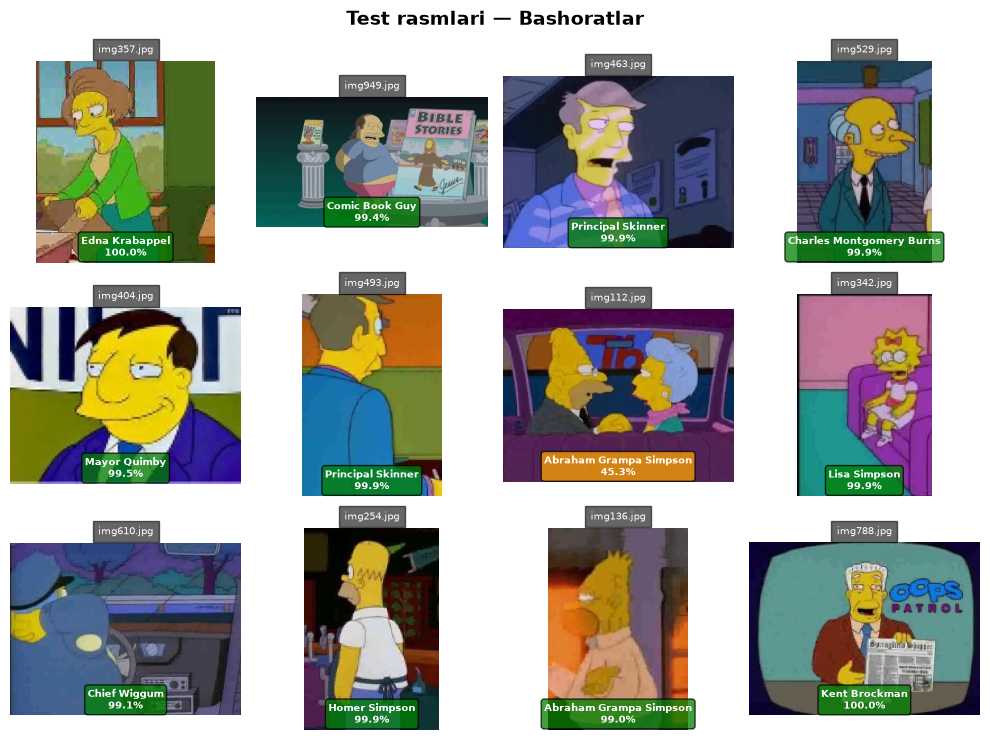

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

@torch.no_grad()
def show_test_predictions(model, test_files, label_encoder, device, n_rows=3, n_cols=4):
    model.eval()
    
    transform = v2.Compose([
        v2.PILToTensor(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize([224, 224]),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    axes = axes.flatten()
    
    indices = np.random.choice(len(test_files), n_rows * n_cols, replace=False)
    
    for ax, idx in zip(axes, indices):
        img_path = test_files[idx]
        image = Image.open(img_path).convert('RGB')
        
        tensor = transform(image).unsqueeze(0).to(device)
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)
        top1_prob, top1_idx = probs.max(dim=1)
        
        predicted_name = label_encoder.inverse_transform([top1_idx.item()])[0]
        predicted_name = predicted_name.replace('_', ' ').title()
        confidence     = top1_prob.item() * 100
        
        ax.imshow(image)
        ax.axis('off')
        
        ax.set_title(img_path.name, fontsize=7, color='white',
                     bbox=dict(facecolor='black', alpha=0.6))
        
        color = 'green' if confidence > 70 else 'orange' if confidence > 40 else 'red'
        ax.text(0.5, 0.02,
                f"{predicted_name}\n{confidence:.1f}%",
                transform=ax.transAxes,
                fontsize=7, fontweight='bold',
                ha='center', va='bottom', color='white',
                bbox=dict(facecolor=color, alpha=0.75, boxstyle='round'))
    
    plt.suptitle('Test rasmlari — Bashoratlar', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_test_predictions(model, test_files, label_encoder, device, n_rows=3, n_cols=4)

predictions.csv saqlandi!


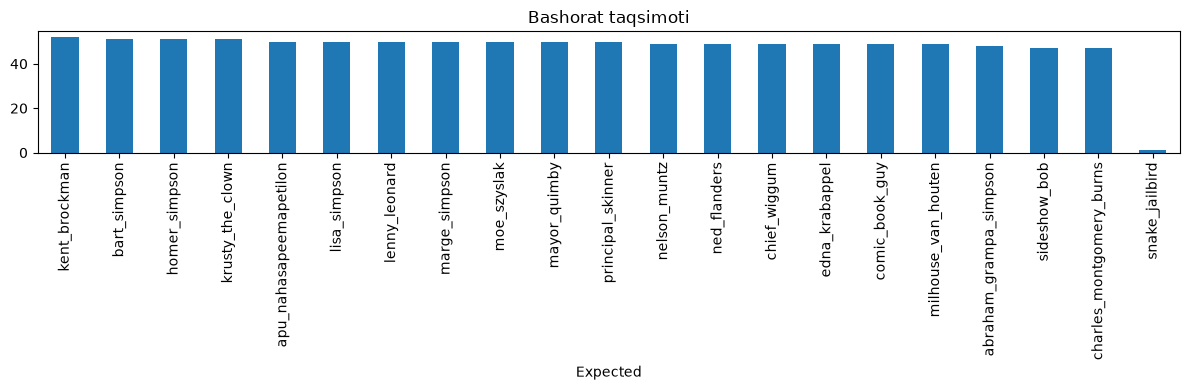

In [24]:
preds_df.to_csv('predictions.csv', index=False)
print('predictions.csv saqlandi!')

preds_df['Expected'].value_counts().plot(kind='bar', figsize=(12, 4), title='Bashorat taqsimoti')
plt.tight_layout()
plt.show()